# Práctica 3 — Parte 2: Comparación de métodos de clustering

Dataset: [Country-data (Kaggle)](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

**Requisito:** ejecutar antes `Practica3_Parte1_CountryData_Acondicionamiento.ipynb` (genera `country_preprocessed.npz`).

Métodos: K-Means, clustering aglomerativo, DBSCAN y Spectral Clustering. Selección de hiperparámetros con el **índice de silueta**.

## Dependencias

Ejecutar la primera celda de código una vez.

In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "scikit-learn>=1.3",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)

Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración

Carga de datos preprocesados desde `datos/CountryData/` (Parte 1).

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_palette("deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def _find_root(rel: str) -> Path:
    c = Path.cwd()
    for base in (c, c.parent):
        if (base / rel).exists():
            return base
    raise FileNotFoundError(f"No se encontró {rel} desde {c}")


ROOT = _find_root("datos/CountryData/Country-data.csv")
DATA_PATH = ROOT / "datos" / "CountryData" / "Country-data.csv"
PROCESSED_NPZ = ROOT / "datos" / "CountryData" / "country_preprocessed.npz"
RAW_SNAPSHOT = ROOT / "datos" / "CountryData" / "country_raw_snapshot.csv"

K_RANGE = range(2, 11)
LINKAGES = ["ward", "complete", "average", "single"]
DBSCAN_EPS_GRID = np.round(np.linspace(0.3, 3.5, 33), 2)
DBSCAN_MIN_SAMPLES_GRID = [3, 4, 5, 6, 8, 10]

if not PROCESSED_NPZ.exists():
    raise FileNotFoundError(
        f"No existe {PROCESSED_NPZ.name}. Ejecute primero la Parte 1."
    )

bundle = np.load(PROCESSED_NPZ, allow_pickle=True)
X_scaled = bundle["X_scaled"]
X_pca = bundle["X_pca"]
countries = bundle["countries"]
FEATURE_COLS = list(bundle["feature_cols"])

if RAW_SNAPSHOT.exists():
    df_raw = pd.read_csv(RAW_SNAPSHOT)
else:
    df_raw = pd.read_csv(DATA_PATH)

print("Datos preprocesados:", PROCESSED_NPZ.resolve())
print("Forma X_scaled:", X_scaled.shape)
print("Variables:", FEATURE_COLS)

Datos preprocesados: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_3\datos\CountryData\country_preprocessed.npz
Forma X_scaled: (167, 9)
Variables: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 2. Utilidades

In [3]:
def silhouette_or_nan(X, labels):
    """Silueta válida solo con >=2 clusters."""
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    try:
        return silhouette_score(X, labels)
    except ValueError:
        return np.nan


def silhouette_dbscan(X, labels, min_non_noise=0.5):
    """Silueta en DBSCAN: solo puntos no ruido (-1) y >=2 clusters."""
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.mean() < min_non_noise:
        return np.nan
    sub_labels = labels[mask]
    if len(np.unique(sub_labels)) < 2:
        return np.nan
    return silhouette_score(X[mask], sub_labels)


def plot_clusters_pca(X_pca, labels, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    labels = np.asarray(labels)
    for lab in sorted(np.unique(labels)):
        mask = labels == lab
        name = "ruido" if lab == -1 else f"cluster {lab}"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.75, s=45)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_silhouette_curve(x_values, scores, xlabel, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x_values, scores, marker="o")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Silueta promedio")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 3. K-Means

Parámetro a tunear: **número de clusters**.

,n_clusters,silhouette
0,2,0.287357
1,3,0.283296
2,4,0.302108
3,5,0.299259
4,6,0.230149
5,7,0.247681
6,8,0.238811
7,9,0.215629
8,10,0.209949


Mejor k = 4, silueta = 0.3021


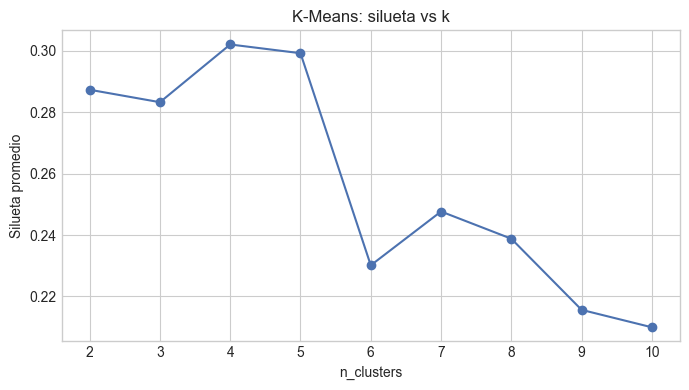

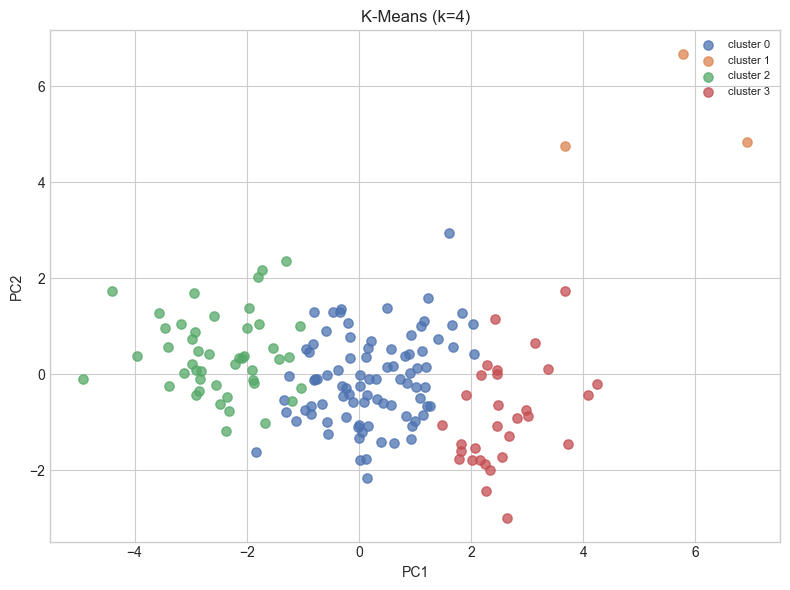

In [4]:
kmeans_rows = []
for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_or_nan(X_scaled, labels)
    kmeans_rows.append({"n_clusters": k, "silhouette": sil})

kmeans_search = pd.DataFrame(kmeans_rows)
display(kmeans_search)

best_k = int(kmeans_search.loc[kmeans_search["silhouette"].idxmax(), "n_clusters"])
kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
labels_kmeans = kmeans_best.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, labels_kmeans)

print(f"Mejor k = {best_k}, silueta = {sil_kmeans:.4f}")
plot_silhouette_curve(kmeans_search["n_clusters"], kmeans_search["silhouette"], "n_clusters", "K-Means: silueta vs k")
plot_clusters_pca(X_pca, labels_kmeans, f"K-Means (k={best_k})")

## 4. Clustering aglomerativo

Parámetros a tunear: **tipo de enlace** (simple, completo, promedio, Ward) y **número de clusters**.

,linkage,n_clusters,silhouette
27,single,2,0.630338
18,average,2,0.630338
28,single,3,0.568913
19,average,3,0.562047
29,single,4,0.534772
20,average,4,0.496960
30,single,5,0.462354
21,average,5,0.385785
31,single,6,0.369496
32,single,7,0.349814


Mejor: linkage=average, k=2, silueta=0.6303


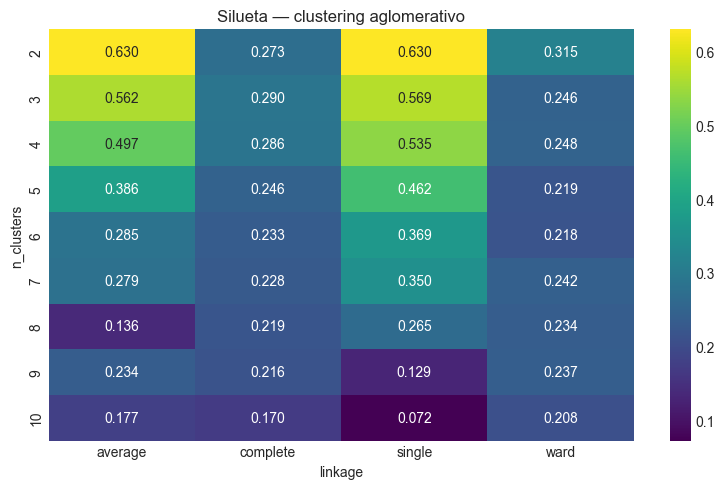

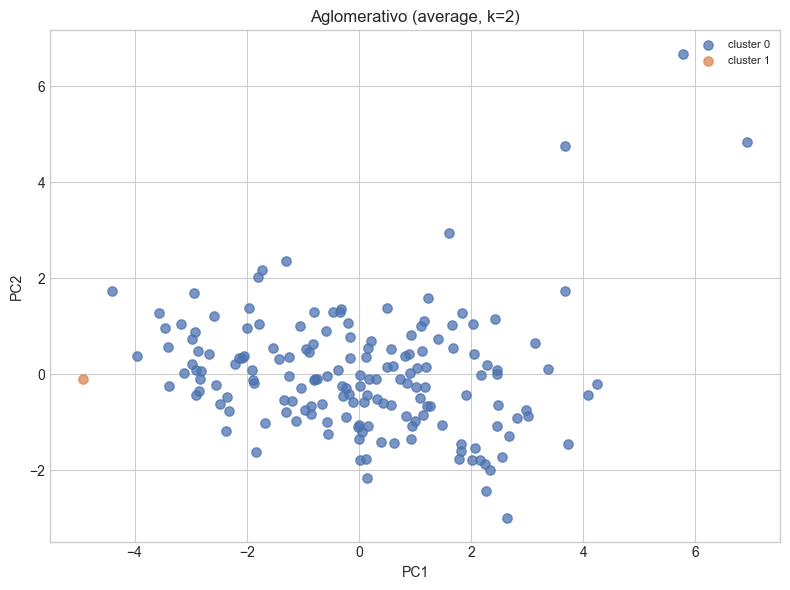

In [5]:
agg_rows = []
for linkage in LINKAGES:
    for k in K_RANGE:
        try:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = model.fit_predict(X_scaled)
            sil = silhouette_or_nan(X_scaled, labels)
        except ValueError:
            sil = np.nan
        agg_rows.append({"linkage": linkage, "n_clusters": k, "silhouette": sil})

agg_search = pd.DataFrame(agg_rows)
display(agg_search.sort_values("silhouette", ascending=False).head(10))

best_agg = agg_search.loc[agg_search["silhouette"].idxmax()]
best_agg_k = int(best_agg["n_clusters"])
best_agg_link = best_agg["linkage"]

agg_best = AgglomerativeClustering(n_clusters=best_agg_k, linkage=best_agg_link)
labels_agg = agg_best.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, labels_agg)

print(f"Mejor: linkage={best_agg_link}, k={best_agg_k}, silueta={sil_agg:.4f}")

pivot_agg = agg_search.pivot(index="n_clusters", columns="linkage", values="silhouette")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_agg, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Silueta — clustering aglomerativo")
plt.tight_layout()
plt.show()

plot_clusters_pca(X_pca, labels_agg, f"Aglomerativo ({best_agg_link}, k={best_agg_k})")

## 5. DBSCAN

Parámetros a tunear: **eps** y **min_samples**.

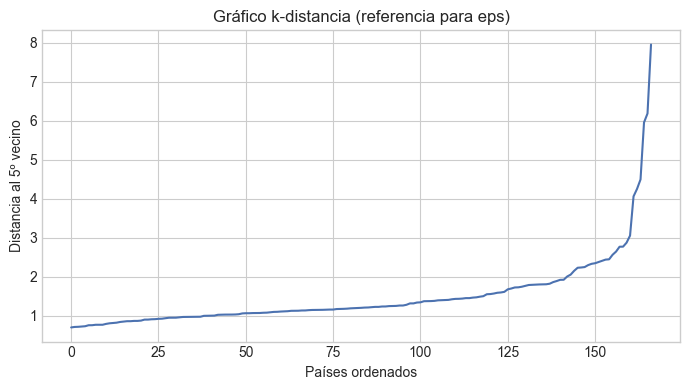

In [6]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_dist)
ax.set_xlabel("Países ordenados")
ax.set_ylabel("Distancia al 5º vecino")
ax.set_title("Gráfico k-distancia (referencia para eps)")
plt.tight_layout()
plt.show()

,eps,min_samples,n_clusters,noise_pct,silhouette
63,1.3,6,2,0.287425,0.413124
62,1.3,5,2,0.275449,0.407751
49,1.1,4,3,0.383234,0.402995
65,1.3,10,3,0.383234,0.395134
58,1.2,8,3,0.425150,0.394079
69,1.4,6,2,0.245509,0.393111
57,1.2,6,3,0.377246,0.392005
56,1.2,5,3,0.317365,0.385026
70,1.4,8,2,0.281437,0.380123
55,1.2,4,3,0.299401,0.369637


Mejor: eps=1.3, min_samples=6, clusters=2, ruido=28.7%, silueta=0.4131


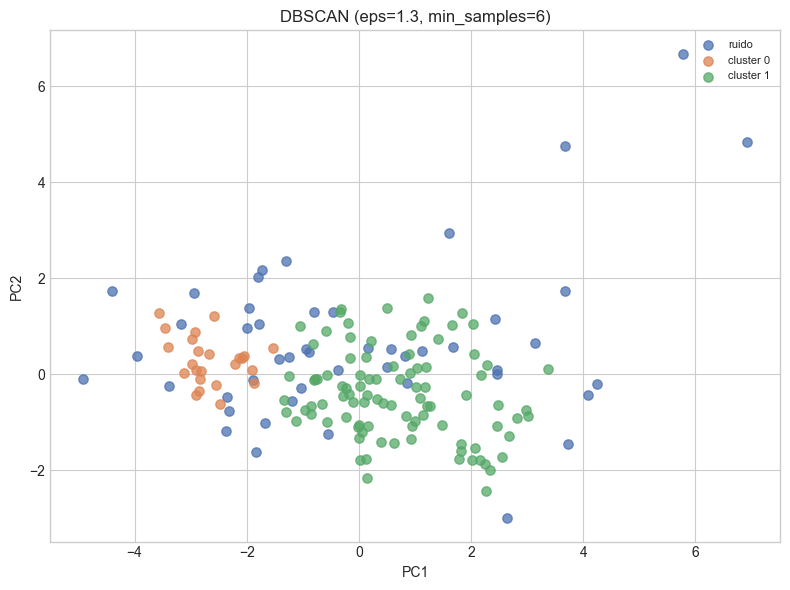

In [7]:
dbscan_rows = []
for eps in DBSCAN_EPS_GRID:
    for ms in DBSCAN_MIN_SAMPLES_GRID:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean()
        sil = silhouette_dbscan(X_scaled, labels)
        dbscan_rows.append(
            {
                "eps": eps,
                "min_samples": ms,
                "n_clusters": n_clusters,
                "noise_pct": noise_pct,
                "silhouette": sil,
            }
        )

dbscan_search = pd.DataFrame(dbscan_rows)
dbscan_valid = dbscan_search.dropna(subset=["silhouette"]).copy()
display(dbscan_valid.sort_values("silhouette", ascending=False).head(10))

best_db = dbscan_valid.loc[dbscan_valid["silhouette"].idxmax()]
best_eps = float(best_db["eps"])
best_ms = int(best_db["min_samples"])

dbscan_best = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_dbscan = dbscan_best.fit_predict(X_scaled)
sil_dbscan = silhouette_dbscan(X_scaled, labels_dbscan)
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
noise_db = (labels_dbscan == -1).mean()

print(
    f"Mejor: eps={best_eps}, min_samples={best_ms}, "
    f"clusters={n_clusters_db}, ruido={noise_db:.1%}, silueta={sil_dbscan:.4f}"
)
plot_clusters_pca(X_pca, labels_dbscan, f"DBSCAN (eps={best_eps}, min_samples={best_ms})")

## 6. Spectral Clustering

Parámetro a tunear: **número de clusters**.

,n_clusters,silhouette
0,2,0.269577
1,3,0.283990
2,4,0.203278
3,5,0.193789
4,6,0.173210
5,7,0.193177
6,8,0.143435
7,9,0.135751
8,10,0.140622


Mejor k = 3, silueta = 0.2840


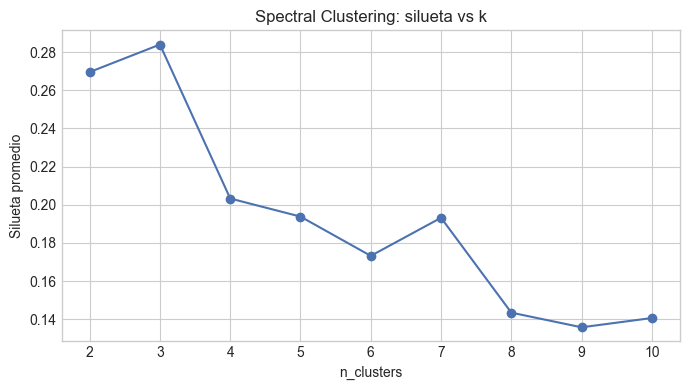

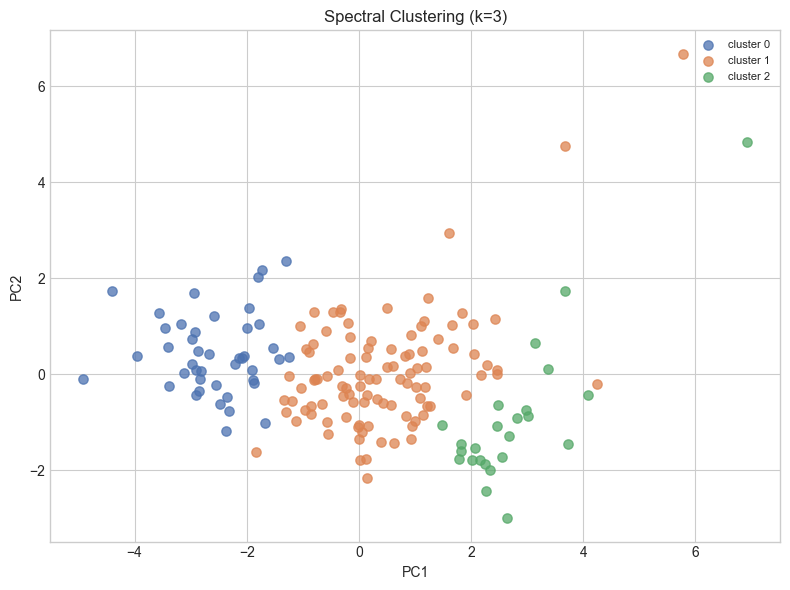

In [8]:
spectral_rows = []
for k in K_RANGE:
    model = SpectralClustering(
        n_clusters=k,
        random_state=RANDOM_STATE,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
    )
    labels = model.fit_predict(X_scaled)
    sil = silhouette_or_nan(X_scaled, labels)
    spectral_rows.append({"n_clusters": k, "silhouette": sil})

spectral_search = pd.DataFrame(spectral_rows)
display(spectral_search)

best_sk = int(spectral_search.loc[spectral_search["silhouette"].idxmax(), "n_clusters"])
spectral_best = SpectralClustering(
    n_clusters=best_sk,
    random_state=RANDOM_STATE,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
)
labels_spectral = spectral_best.fit_predict(X_scaled)
sil_spectral = silhouette_score(X_scaled, labels_spectral)

print(f"Mejor k = {best_sk}, silueta = {sil_spectral:.4f}")
plot_silhouette_curve(
    spectral_search["n_clusters"],
    spectral_search["silhouette"],
    "n_clusters",
    "Spectral Clustering: silueta vs k",
)
plot_clusters_pca(X_pca, labels_spectral, f"Spectral Clustering (k={best_sk})")

## 7. Perfiles de clusters (K-Means)

In [9]:
profile = df_raw.copy()
profile["cluster"] = labels_kmeans
cluster_means = profile.groupby("cluster")[FEATURE_COLS].mean().round(1)
display(cluster_means)

for c in sorted(profile["cluster"].unique()):
    n = (profile["cluster"] == c).sum()
    examples = profile.loc[profile["cluster"] == c, "country"].head(5).tolist()
    print(f"Cluster {c} (n={n}): {', '.join(examples)} ...")

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,21.7,41.3,6.3,48.1,12972.4,7.4,72.8,2.3,6912.6
1,4.1,176.0,6.8,156.7,64033.3,2.5,81.4,1.4,57566.7
2,93.8,28.8,6.3,42.1,3739.0,12.1,59.2,5.1,1826.1
3,5.0,45.8,9.2,39.7,45250.0,2.7,80.4,1.8,43333.3


Cluster 0 (n=88): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia ...
Cluster 1 (n=3): Luxembourg, Malta, Singapore ...
Cluster 2 (n=46): Afghanistan, Angola, Benin, Burkina Faso, Burundi ...
Cluster 3 (n=30): Australia, Austria, Belgium, Brunei, Canada ...


## 8. Tabla comparativa

,Método,Parámetros óptimos,Silueta,Clusters
1,Aglomerativo,"linkage=average, n_clusters=2",0.6303,2
2,DBSCAN,"eps=1.3, min_samples=6",0.4131,2
0,K-Means,n_clusters=4,0.3021,4
3,Spectral,n_clusters=3,0.2840,3


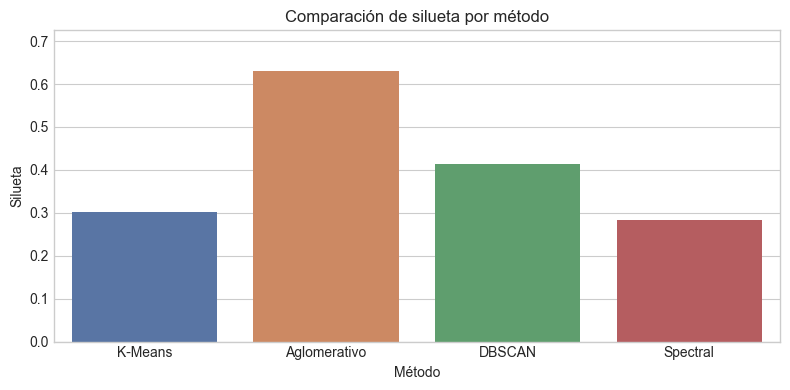

In [10]:
comparison = pd.DataFrame(
    [
        {
            "Método": "K-Means",
            "Parámetros óptimos": f"n_clusters={best_k}",
            "Silueta": round(sil_kmeans, 4),
            "Clusters": best_k,
        },
        {
            "Método": "Aglomerativo",
            "Parámetros óptimos": f"linkage={best_agg_link}, n_clusters={best_agg_k}",
            "Silueta": round(sil_agg, 4),
            "Clusters": best_agg_k,
        },
        {
            "Método": "DBSCAN",
            "Parámetros óptimos": f"eps={best_eps}, min_samples={best_ms}",
            "Silueta": round(sil_dbscan, 4),
            "Clusters": n_clusters_db,
        },
        {
            "Método": "Spectral",
            "Parámetros óptimos": f"n_clusters={best_sk}",
            "Silueta": round(sil_spectral, 4),
            "Clusters": best_sk,
        },
    ]
)
display(comparison.sort_values("Silueta", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=comparison, x="Método", y="Silueta", hue="Método", legend=False, ax=ax)
ax.set_ylim(0, max(comparison["Silueta"].max() * 1.15, 0.1))
ax.set_title("Comparación de silueta por método")
plt.tight_layout()
plt.show()

## 9. Análisis comparativo y conclusiones

**K-Means (k = 4, silueta ≈ 0,302).** La silueta máxima está en k = 4; con más clusters cae (p. ej. ≈ 0,23 en k = 6). Los cuatro grupos tienen sentido: países vulnerables (cluster 2, n ≈ 46), ingreso medio (0, n ≈ 88), desarrollados (3, n ≈ 30) y un mini-grupo de hubs (Luxembourg, Malta, Singapore). Es la partición **más interpretable**, aunque la silueta sea modesta por solapamiento en PCA.

**Aglomerativo (average, k = 2, silueta ≈ 0,630).** Lidera la tabla, pero en PCA un cluster es **un solo país** y el otro reúne 166: la silueta alta viene del efecto *cadena* de *average/single*, no de una segmentación útil. Ward/complete puntúan peor (≈ 0,25–0,31) pero dan grupos más equilibrados.

**DBSCAN (eps = 1,3, min_samples = 6, silueta ≈ 0,413).** Segundo en silueta, con **2 clusters** y **~29 % ruido**: detecta núcleos densos y deja atípicos fuera. Complementa a K-Means; ajustar `eps` y `min_samples` es lo más costoso (rejilla 2D + gráfico k-distancia).

**Spectral (k = 3, silueta ≈ 0,284).** Tres franjas en PC1, similar a K-Means con pocos clusters; no mejora silueta ni perfiles respecto a k = 4 en K-Means.

### Tabla comparativa

| Método | Mejores parámetros | Silueta | n° clusters | Complejidad del ajuste | Valoración |
|--------|-------------------|---------|-------------|------------------------|------------|
| **K-Means** | k = 4 | ≈ 0,302 | 4 | Baja (solo k) | Mejor equilibrio interpretación / silueta |
| **Aglomerativo** | average, k = 2 | ≈ 0,630 | 2 | Media (enlace × k) | Silueta alta pero partición poco útil |
| **DBSCAN** | eps = 1,3, min_samples = 6 | ≈ 0,413 | 2 (+ ruido) | Alta (eps × min_samples) | Bueno para núcleos densos y outliers (~29 % ruido) |
| **Spectral** | k = 3 | ≈ 0,284 | 3 | Media-alta (k + afinidad) | Similar a K-Means, sin ventaja clara |

**Complejidad de parámetros:** baja en K-Means y Spectral (solo k); media en aglomerativo (enlace × k); alta en DBSCAN (`eps`, `min_samples`).

**Conclusión.** Orden por silueta: aglomerativo > DBSCAN > K-Means > Spectral, pero **no basta la métrica**: conviene mirar tamaño de clusters y % de ruido. Para este dataset, **K-Means (k = 4)** es la mejor opción global; **DBSCAN** sirve para outliers. El aglomerativo con *average* y k = 2 maximiza silueta sin aportar grupos útiles.